# Importing Neccessary Libraries


In [28]:
import numpy as np
import pandas as pd

In [29]:
import pandas as pd

# Step 1: Load the dataset from the text file
file_path = 'household_power_consumption.txt'

# Read the file, assuming the columns are separated by a semicolon (`;`)
data = pd.read_csv(file_path, sep=';', header=0)

# Step 2: Preview the first few rows to make sure the data is loaded correctly
print("First few rows of the dataset:")
print(data.head())

# Step 3: Save the data as a CSV file
output_csv_path = 'datas.csv'
data.to_csv(output_csv_path, index=False)

print(f"Data has been converted and saved as '{output_csv_path}'")


C:\Users\1005\AppData\Local\Temp\ipykernel_4664\3583587217.py:7: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path, sep=';', header=0)


First few rows of the dataset:
         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  
Data has been converted and saved as 'datas.csv'


# # Data collection

In [30]:
df = pd.read_csv('datas.csv')

C:\Users\1005\AppData\Local\Temp\ipykernel_4664\3127979951.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('datas.csv')


In [31]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [32]:
df.shape

(2075259, 9)

In [33]:
df.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0
2075258,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


In [34]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64


In [35]:
df.dtypes

Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object

# # Data Pre-processing

In [36]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [37]:
df.describe()

,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [38]:
from skimpy import skim
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                 Data Types                                                                │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                         │
│ ┃ Dataframe         ┃ Values  ┃ ┃ Column Type ┃ Count ┃                                                         │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                         │
│ │ Number of rows    │ 2075259 │ │ string      │ 2     │                                                         │
│ │ Number of columns │ 3       │ │ float64     │ 1     │                                                         │
│ └───────────────────┴─────────┘ └─────────────┴───────┘                                                         │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column           ┃ NA     ┃ NA %                 ┃ mean   ┃ sd     ┃ p0  ┃ p25 ┃ p50 ┃ p75 ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ Sub_metering_3   │  25979 │   1.2518437457686005 │  6.458 │  8.437 │   0 │   0 │   1 │  17 │   31 │  ▇  ▃  │  │
│ └──────────────────┴────────┴──────────────────────┴────────┴────────┴─────┴─────┴─────┴─────┴──────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃        ┃    ┃      ┃          ┃            ┃          ┃          ┃ chars per   ┃ words per   ┃             ┃  │
│ ┃ column ┃ NA ┃ NA % ┃ shortest ┃ longest    ┃ min      ┃ max      ┃ row         ┃ row         ┃ total words ┃  │
│ ┡━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ Date   │  0 │    0 │ 1/1/2007 │ 16/12/2006 │ 1/1/2007 │ 9/9/2010 │        8.95 │           1 │     2075259 │  │
│ │ Time   │  0 │    0 │ 17:24:00 │ 17:24:00   │ 00:00:00 │ 23:59:00 │           8 │           1 │     2075259 │  │
│ └────────┴────┴──────┴──────────┴────────────┴──────────┴──────────┴─────────────┴─────────────┴─────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [39]:
df = df.apply(pd.to_numeric, errors='coerce')

# Step 3: Handle missing values
df.fillna(df.median(), inplace=True)


In [40]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 Date                     2075259
Time                     2075259
Global_active_power            0
Global_reactive_power          0
Voltage                        0
Global_intensity               0
Sub_metering_1                 0
Sub_metering_2                 0
Sub_metering_3                 0
dtype: int64


In [41]:
df=df.drop(columns=['Date','Time'])

In [42]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Save the DataFrame as a CSV file
df.to_csv('n_data.csv', index=False)


Missing values in each column:
 Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [43]:
f_df=pd.read_csv('n_data.csv', nrows=10000)

# # EDA(Exploratory Data Analysis)

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

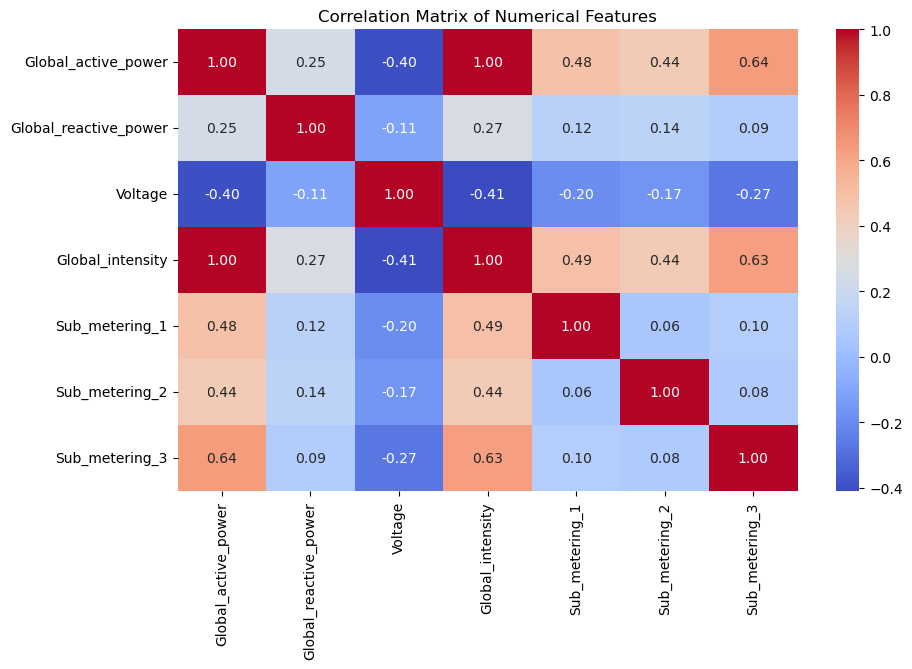

In [45]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# # Data splitting

In [46]:
x=f_df.drop(columns='Global_active_power')
y=f_df['Global_active_power']

In [47]:
y.value_counts()

Global_active_power
0.208    134
0.206    103
0.210     93
0.204     76
0.300     60
        ... 
4.148      1
4.182      1
4.168      1
3.944      1
4.658      1
Name: count, Length: 2158, dtype: int64

# # APPLYING SMOTE TO BALANCE THE DATA

In [64]:

from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((7000, 6), (3000, 6), (7000,), (3000,))

In [65]:
x_train_df = pd.DataFrame(x_train)
x_train_df.to_csv('x_train.csv', index=False)

# ALGORITHM IMPLEMENTATION

In [50]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor()

# Train the model using the training data
rf_model.fit(x_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(x_test)

# Evaluate the model performance using Mean Squared Error (MSE) and R^2 score
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Output the performance metrics
print(f"Random Forest Model Performance:")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"R^2 Score: {r2_rf:.4f}")


Random Forest Model Performance:
Mean Squared Error (MSE): 0.0027
R^2 Score: 0.9985


In [51]:
import joblib 

joblib.dump(rf_model, "RF.joblib")

['RF.joblib']

In [54]:
# Import necessary libraries
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Extra Trees Regressor model
extra_tree_model = ExtraTreesRegressor()

# Train the model using the training data
extra_tree_model.fit(x_train, y_train)

# Make predictions on the test data
y_pred_et = extra_tree_model.predict(x_test)

# Evaluate the model performance using Mean Squared Error (MSE) and R^2 score
mse_et = mean_squared_error(y_test, y_pred_et)
r2_et = r2_score(y_test, y_pred_et)

# Output the performance metrics
print(f"Extra Tree Regressor Performance:")
print(f"Mean Squared Error (MSE): {mse_et:.4f}")
print(f"R^2 Score: {r2_et:.4f}")


Extra Tree Regressor Performance:
Mean Squared Error (MSE): 0.0028
R^2 Score: 0.9984


In [55]:
# Import necessary libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Decision Tree Regressor model
dt_regressor = DecisionTreeRegressor()

# Train the model using the training data
dt_regressor.fit(x_train, y_train)

# Make predictions on the test data
y_pred_dt = dt_regressor.predict(x_test)

# Evaluate the model performance using Mean Squared Error (MSE) and R^2 score
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Output the performance metrics
print(f"Decision Tree Regressor Performance:")
print(f"Mean Squared Error (MSE): {mse_dt:.4f}")
print(f"R^2 Score: {r2_dt:.4f}")


Decision Tree Regressor Performance:
Mean Squared Error (MSE): 0.0044
R^2 Score: 0.9975


In [56]:
# Import necessary libraries
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Gradient Boosting Regressor model
gb_regressor = GradientBoostingRegressor()

# Train the model using the training data
gb_regressor.fit(x_train, y_train)

# Make predictions on the test data
y_pred_gb = gb_regressor.predict(x_test)

# Evaluate the model performance using Mean Squared Error (MSE) and R^2 score
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Output the performance metrics
print(f"Gradient Boosting Regressor Performance:")
print(f"Mean Squared Error (MSE): {mse_gb:.4f}")
print(f"R^2 Score: {r2_gb:.4f}")


Gradient Boosting Regressor Performance:
Mean Squared Error (MSE): 0.0031
R^2 Score: 0.9983


In [58]:
# Import necessary libraries
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the XGBoost Regressor model
xgb_regressor = xgb.XGBRegressor()

# Train the model using the training data
xgb_regressor.fit(x_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_regressor.predict(x_test)

# Evaluate the model performance using Mean Squared Error (MSE) and R^2 score
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Output the performance metrics
print(f"XGBoost Regressor Performance:")
print(f"Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"R^2 Score: {r2_xgb:.4f}")


XGBoost Regressor Performance:
Mean Squared Error (MSE): 0.0029
R^2 Score: 0.9984


In [59]:
# Import necessary libraries
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the K-Nearest Neighbors Regressor model
knn_regressor = KNeighborsRegressor()

# Train the model using the training data
knn_regressor.fit(x_train, y_train)

# Make predictions on the test data
y_pred_knn = knn_regressor.predict(x_test)

# Evaluate the model performance using Mean Squared Error (MSE) and R^2 score
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

# Output the performance metrics
print(f"K-Nearest Neighbors Regressor Performance:")
print(f"Mean Squared Error (MSE): {mse_knn:.4f}")
print(f"R^2 Score: {r2_knn:.4f}")


K-Nearest Neighbors Regressor Performance:
Mean Squared Error (MSE): 0.0101
R^2 Score: 0.9944


In [60]:
# Import necessary libraries
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Support Vector Regressor model
svr_model = SVR()

# Train the model using the training data
svr_model.fit(x_train, y_train)

# Make predictions on the test data
y_pred_svr = svr_model.predict(x_test)

# Evaluate the model performance using Mean Squared Error (MSE) and R^2 score
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

# Output the performance metrics
print(f"Support Vector Regressor Performance:")
print(f"Mean Squared Error (MSE): {mse_svr:.4f}")
print(f"R^2 Score: {r2_svr:.4f}")


Support Vector Regressor Performance:
Mean Squared Error (MSE): 0.0079
R^2 Score: 0.9956


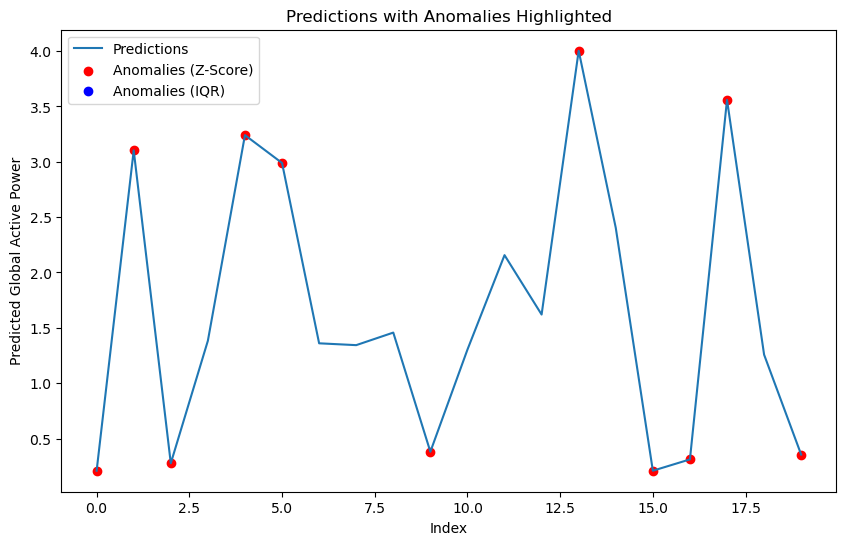

Anomalies based on Z-Score (True means anomaly): [ True  True  True False  True  True False False False  True False False
 False  True False  True  True  True False  True]


In [66]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Step 1: Load the pre-trained Random Forest model from joblib
rf_model = joblib.load('RF.joblib')  # Assuming the model is saved as 'RF.joblib'

# Step 2: Predict the first 20 values from x_train using the loaded model
predictions = rf_model.predict(x_train[:20])

# Step 3: Anomaly detection using Z-Score
predictions_zscore = (predictions - np.mean(predictions)) / np.std(predictions)
threshold = 1  # Lower threshold for anomaly detection
anomalies_zscore = np.abs(predictions_zscore) > threshold

# Step 4: Anomaly detection using IQR method
Q1 = np.percentile(predictions, 25)
Q3 = np.percentile(predictions, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
anomalies_iqr = (predictions < lower_bound) | (predictions > upper_bound)

# Step 5: Visualize predictions with anomalies
plt.figure(figsize=(10, 6))
plt.plot(predictions, label="Predictions")
plt.scatter(np.where(anomalies_zscore)[0], predictions[anomalies_zscore], color='red', label='Anomalies (Z-Score)')
plt.scatter(np.where(anomalies_iqr)[0], predictions[anomalies_iqr], color='blue', label='Anomalies (IQR)')
plt.title("Predictions with Anomalies Highlighted")
plt.xlabel("Index")
plt.ylabel("Predicted Global Active Power")
plt.legend()
plt.show()

# Step 6: Print anomalies based on Z-Score and IQR
print(f"Anomalies based on Z-Score (True means anomaly): {anomalies_zscore}")

# Step 7: Save predictions with anomaly flags
predictions_df = pd.DataFrame({
    'Predicted_Global_active_power': predictions,
    'Anomaly_Flag_Z-Score': anomalies_zscore,
    'Anomaly_Flag_IQR': anomalies_iqr
})

predictions_df.to_csv('predictions_for_first_20_with_anomalies.csv', index=False)
